# Phase 11 — KMeans Clustering: Country Economic Archetypes

**Objective:** Segment countries into economic archetypes based on their 
structural characteristics, and compare how those archetypes changed 
between 2019 (pre-COVID) and 2022 (post-COVID).

**Key question:** Did COVID fundamentally restructure which countries 
belong to which economic cluster — or did most countries stay in the 
same structural position?

## Approach

Rather than clustering all 3,552 country-year records, we focus on 
two specific years — **2019** (last pre-COVID year) and **2022** 
(post-COVID, peak inflation year) — and compare how countries moved 
between clusters.

**Why compare 2019 and 2022 specifically?**
- 2019 represents the last "normal" year before COVID disruption
- 2022 represents the post-COVID world — supply chain disruption, 
  energy price spikes, global inflation surge
- The 3-year gap is long enough to see structural shifts but short 
  enough that we're comparing the same countries under different conditions

**Critical design decision — one model, two years:**
We fit a single KMeans model on the combined 2019+2022 data, then 
predict cluster labels for each year separately. This is essential 
for comparability — if we fit two separate models, cluster labels 
would be arbitrary and comparing "cluster 1 in 2019" to "cluster 1 
in 2022" would be meaningless. One model ensures the clusters mean 
the same thing in both years.

## Model choice — why KMeans

KMeans partitions countries into k groups by minimising within-cluster 
variance — each country is assigned to its nearest cluster centroid 
in feature space.

**Why KMeans and not hierarchical clustering or DBSCAN?**

- **KMeans** — fast, scalable, produces equal-priority clusters, 
  works well when we have a target k in mind. The right choice when 
  we want a fixed number of interpretable archetypes.
- **Hierarchical clustering** — builds a dendrogram showing nested 
  relationships. Better for exploring structure without a fixed k, 
  but produces the same result at a given k as KMeans for well-separated 
  clusters. More useful when the hierarchy itself is meaningful — e.g. 
  "Sub-Saharan Africa clusters within the broader low-income cluster."
- **DBSCAN** — finds clusters of arbitrary shape and identifies outliers. 
  Better for geographic or spatial data where clusters aren't spherical. 
  Less appropriate here since economic indicators tend to produce 
  roughly spherical clusters in feature space.

**Limitation of KMeans:** Assumes spherical clusters of roughly equal 
size, and is sensitive to outliers. We address the outlier sensitivity 
by log-transforming inflation (which had extreme values up to 500%+) 
before clustering.

## Features used

```python
FEATURES_SCALED = [
    'log_gdp',           # economy size (log-transformed)
    'log_inflation',     # price stability (log-transformed)
    'unemployment_rate', # labour market health
    'exports_pct_gdp',   # trade openness
    'gdp_growth_rate',   # economic momentum
    'income_group_enc',  # development level (ordinal encoded)
]
```

All features are standardised (zero mean, unit variance) before 
clustering — KMeans is distance-based and sensitive to scale, so 
a country with GDP of $1 trillion would otherwise dominate 
a country with unemployment of 10%.

## MLflow tracking

This experiment is logged to the `country_clustering` experiment 
in MLflow at `http://localhost:5000`.

In [1]:
import os
import pandas as pd
import numpy as np
import psycopg2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import mlflow
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import warnings
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
pio.renderers.default = "iframe"

warnings.filterwarnings('ignore')

# ── Load data ─────────────────────────────────────────────────────────────────
conn = psycopg2.connect(
    host=os.getenv("POSTGRES_HOST", "postgres"),
    port=os.getenv("POSTGRES_PORT", 5432),
    dbname=os.getenv("POSTGRES_DB", "worldbank"),
    user=os.getenv("POSTGRES_USER", "de"),
    password=os.getenv("POSTGRES_PASSWORD", "de"),
)

df = pd.read_sql("SELECT * FROM marts.economic_indicators", conn)
conn.close()

print(f"Loaded: {df.shape}")
df.head(3)

Loaded: (3552, 16)


,country_code,country_name,region,income_group,capital,year,gdp_usd,inflation_rate,unemployment_rate,exports_pct_gdp,population,gdp_growth_rate,log_gdp,crisis_flag,is_extreme_inflation,income_group_enc
0,AFG,Afghanistan,South Asia,Low income,Kabul,2023,1.715223e+10,-4.6447,14.008,16.8528,41454761.0,18.313762,23.565394,0.0,0.0,0
1,AFG,Afghanistan,South Asia,Low income,Kabul,2022,1.449724e+10,13.7121,14.100,18.3800,40578842.0,1.663734,23.397224,1.0,0.0,0
2,AFG,Afghanistan,South Asia,Low income,Kabul,2021,1.426000e+10,5.1332,12.006,14.3422,40000412.0,-28.542563,23.380724,0.0,0.0,0


In [2]:
# ── Filter to 2019 and 2022, stack combined ───────────────────────────────────
FEATURES = [
    'log_gdp',
    'inflation_rate',
    'unemployment_rate',
    'exports_pct_gdp',
    'gdp_growth_rate',
    'income_group_enc',
]

YEARS = [2019, 2022]

# Filter to both years
df_both = df[df['year'].isin(YEARS)].copy()

# Log-transform inflation to handle skew
df_both['log_inflation'] = np.log1p(df_both['inflation_rate'].clip(lower=0))

FEATURES_SCALED = [
    'log_gdp',
    'log_inflation',
    'unemployment_rate',
    'exports_pct_gdp',
    'gdp_growth_rate',
    'income_group_enc',
]

# Drop rows with missing features
df_model = df_both[FEATURES_SCALED + ['country_code', 'country_name', 
                                       'region', 'year', 'income_group']].dropna()

print(f"2019 rows: {(df_model['year']==2019).sum()}")
print(f"2022 rows: {(df_model['year']==2022).sum()}")
print(f"Total rows for clustering: {len(df_model)}")
print(f"\nFeatures: {FEATURES_SCALED}")

2019 rows: 132
2022 rows: 131
Total rows for clustering: 263

Features: ['log_gdp', 'log_inflation', 'unemployment_rate', 'exports_pct_gdp', 'gdp_growth_rate', 'income_group_enc']


## Choosing k — elbow method and silhouette score

Two standard methods for selecting the number of clusters:

**Elbow method** plots inertia (within-cluster sum of squares) against k.
The "elbow" — where adding more clusters gives diminishing returns — 
suggests k=4 or k=5. The curve flattens noticeably after k=4.

**Silhouette score** measures how similar each point is to its own 
cluster versus neighbouring clusters. Higher is better. Peak score 
of 0.2475 at k=4, confirming the elbow suggestion.

Silhouette scores of 0.20-0.25 are modest — expected for economic data 
where countries exist on a continuum rather than falling into perfectly 
separated groups. The scores confirm k=4 gives the best available 
separation, not that the clusters are perfectly distinct.

**Decision: k=4**, supported by both methods.

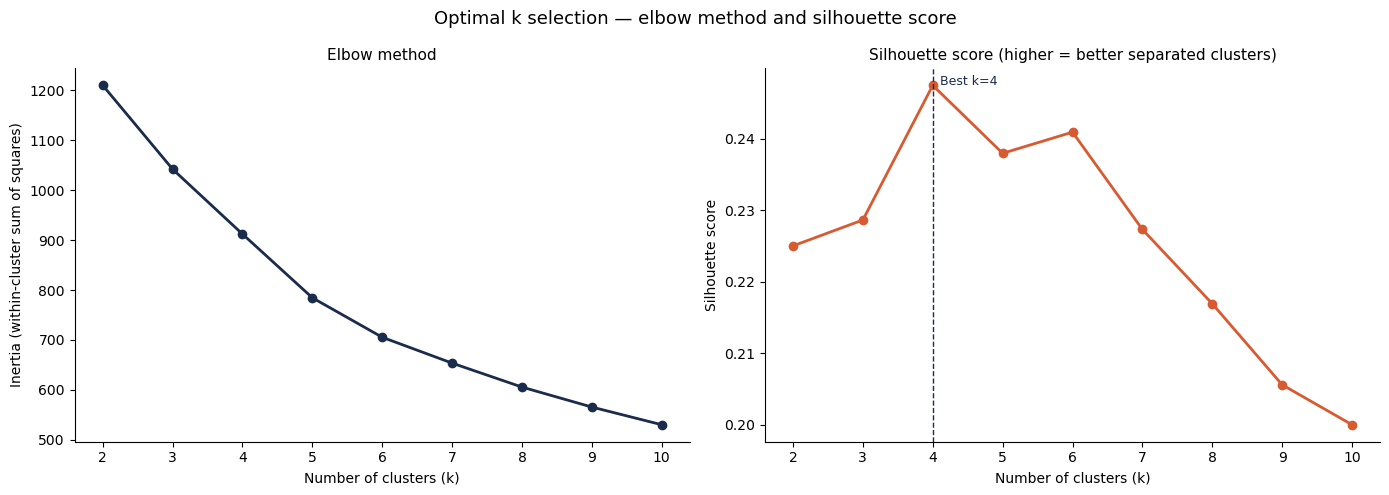


Silhouette scores by k:
  k=2: 0.2250
  k=3: 0.2286
  k=4: 0.2475
  k=5: 0.2380
  k=6: 0.2409
  k=7: 0.2273
  k=8: 0.2169
  k=9: 0.2056
  k=10: 0.2000

Best k by silhouette: 4


In [3]:
# ── Find optimal k — elbow method + silhouette score ─────────────────────────
X = df_model[FEATURES_SCALED].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertias = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Optimal k selection — elbow method and silhouette score', 
             fontsize=13, fontweight='500')

# Elbow
ax = axes[0]
ax.plot(k_range, inertias, 'o-', color='#1B2B4B', linewidth=2, markersize=6)
ax.set_xlabel('Number of clusters (k)')
ax.set_ylabel('Inertia (within-cluster sum of squares)')
ax.set_title('Elbow method', fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Silhouette
ax = axes[1]
ax.plot(k_range, silhouette_scores, 'o-', color='#D85A30', linewidth=2, markersize=6)
ax.set_xlabel('Number of clusters (k)')
ax.set_ylabel('Silhouette score')
ax.set_title('Silhouette score (higher = better separated clusters)', fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Mark best silhouette
best_k = k_range[np.argmax(silhouette_scores)]
ax.axvline(best_k, color='#1B2B4B', linewidth=1, linestyle='--')
ax.text(best_k + 0.1, max(silhouette_scores), f'Best k={best_k}', 
        fontsize=9, color='#1B2B4B')

plt.tight_layout()
plt.savefig('01_optimal_k.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSilhouette scores by k:")
for k, s in zip(k_range, silhouette_scores):
    print(f"  k={k}: {s:.4f}")
print(f"\nBest k by silhouette: {best_k}")

## Cluster profiles — four economic archetypes

One KMeans model fitted on combined 2019+2022 data so cluster labels 
are directly comparable across both years.

In [4]:
# ── Fit final KMeans model with k=4 ──────────────────────────────────────────
K = 4

kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
df_model = df_model.copy()
df_model['cluster'] = kmeans.fit_predict(X_scaled)

# Split back into 2019 and 2022
df_2019 = df_model[df_model['year'] == 2019].copy()
df_2022 = df_model[df_model['year'] == 2022].copy()

print(f"=== Cluster distribution 2019 ===")
print(df_2019['cluster'].value_counts().sort_index())
print(f"\n=== Cluster distribution 2022 ===")
print(df_2022['cluster'].value_counts().sort_index())

# Cluster profiles — mean of each feature per cluster
print(f"\n=== Cluster profiles (mean across both years) ===")
profile = df_model.groupby('cluster')[FEATURES_SCALED].mean().round(2)
print(profile.to_string())

=== Cluster distribution 2019 ===
cluster
0     2
1    24
2    62
3    44
Name: count, dtype: int64

=== Cluster distribution 2022 ===
cluster
0    22
1    13
2    52
3    44
Name: count, dtype: int64

=== Cluster profiles (mean across both years) ===
         log_gdp  log_inflation  unemployment_rate  exports_pct_gdp  gdp_growth_rate  income_group_enc
cluster                                                                                               
0          25.60           2.52               7.76            39.69            27.94              1.79
1          24.56           1.48              16.28            42.79             1.00              1.78
2          26.63           1.47               4.92            59.28             1.44              2.68
3          24.22           2.15               5.09            25.41             3.32              0.66


| Cluster | Name | Key characteristics |
|---|---|---|
| 0 | High inflation / rapid growth | High log_inflation (2.52), high GDP growth (27.9%) |
| 1 | High unemployment / stagnation | Unemployment 16.3%, GDP growth only 1.0% |
| 2 | Large open economies | Highest log_gdp (26.6), exports 59.3% of GDP, higher income group |
| 3 | Low-income domestic economies | Lowest log_gdp (24.2), exports only 25.3%, lowest income group (0.66) |

**Cluster 2 (Large open economies)** is the largest and most stable — 
62 countries in 2019, 52 in 2022. These are trade-integrated economies 
across the income spectrum: developed economies (Germany, Japan) alongside 
upper-middle-income open economies (Malaysia, Thailand).

**Cluster 3 (Low-income domestic economies)** is equally stable at 44 
countries in both years — Sub-Saharan African and South Asian lower-income 
countries whose economic structure didn't fundamentally change between 
2019 and 2022.

**Cluster 0 (High inflation / rapid growth)** is the most dramatic story — 
just 2 countries in 2019, exploding to 22 in 2022. This is COVID's 
inflation fingerprint in the data.

**Cluster 1 (High unemployment / stagnation)** shrank from 24 to 13 — 
some of these countries escaped stagnation, though as we'll see, many 
moved into the inflation cluster rather than recovering to stable growth.

In [5]:
# ── Name the clusters ─────────────────────────────────────────────────────────
CLUSTER_NAMES = {
    0: 'High inflation / rapid growth',
    1: 'High unemployment / stagnation',
    2: 'Large open economies',
    3: 'Low-income domestic economies',
}

CLUSTER_COLORS = {
    0: '#D85A30',
    1: '#7F77DD',
    2: '#1B2B4B',
    3: '#0F6E56',
}

df_model['cluster_name'] = df_model['cluster'].map(CLUSTER_NAMES)
df_2019['cluster_name'] = df_2019['cluster'].map(CLUSTER_NAMES)
df_2022['cluster_name'] = df_2022['cluster'].map(CLUSTER_NAMES)

print("Cluster names assigned.")

Cluster names assigned.


In [6]:
# ── PCA for 2D visualisation ──────────────────────────────────────────────────
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)
df_model['pca1'] = coords[:, 0]
df_model['pca2'] = coords[:, 1]

print(f"PCA explained variance: {pca.explained_variance_ratio_.round(3)}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.1%}")

PCA explained variance: [0.323 0.182]
Total variance explained: 50.6%


## PCA projection — 2019 vs 2022

In [7]:
# Build combined dataframe with PCA coords already computed
df_plot = df_model.copy()
df_plot['cluster_name'] = df_plot['cluster'].map(CLUSTER_NAMES)  # add this line
df_plot['year_str'] = df_plot['year'].astype(str)

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=['2019 (pre-COVID)', '2022 (post-COVID)'],
    shared_yaxes=True
)

color_map = {
    'High inflation / rapid growth':   '#D85A30',
    'High unemployment / stagnation':  '#7F77DD',
    'Large open economies':            '#1B2B4B',
    'Low-income domestic economies':   '#0F6E56',
}

for col, year in zip([1, 2], [2019, 2022]):
    subset = df_plot[df_plot['year'] == year]
    for cluster_name, color in color_map.items():
        mask = subset['cluster_name'] == cluster_name
        grp  = subset[mask]
        fig.add_trace(
            go.Scatter(
                x=grp['pca1'],
                y=grp['pca2'],
                mode='markers',
                name=cluster_name,
                marker=dict(color=color, size=8, opacity=0.8,
                            line=dict(width=0.5, color='white')),
                text=grp['country_name'],
                customdata=grp[['country_code','income_group',
                                 'gdp_growth_rate','log_inflation',
                                 'unemployment_rate']].values,
                hovertemplate=(
                    "<b>%{text}</b> (%{customdata[0]})<br>"
                    "Income group: %{customdata[1]}<br>"
                    "GDP growth: %{customdata[2]:.1f}%<br>"
                    "Log inflation: %{customdata[3]:.2f}<br>"
                    "Unemployment: %{customdata[4]:.1f}%<br>"
                    "<extra></extra>"
                ),
                showlegend=(col == 1),
            ),
            row=1, col=col
        )

fig.update_layout(
    title=dict(text='Country economic clusters — 2019 vs 2022 (PCA projection)',
               font=dict(size=14)),
    height=600,
    plot_bgcolor='white',
    paper_bgcolor='white',
    legend=dict(
        orientation='h',
        yanchor='bottom',
        y=-0.25,
        xanchor='center',
        x=0.5,
        font=dict(size=10)
    )
)

fig.update_xaxes(showgrid=True, gridcolor='#F0EDE8', zeroline=False)
fig.update_yaxes(showgrid=True, gridcolor='#F0EDE8', zeroline=False)

fig.show()

Two principal components explain 50.6% of variance (PC1: 32.3%, PC2: 18.2%).
The remaining variance reflects dimensions not captured in 2D.

The visual contrast between 2019 and 2022 is striking:

**2019** — the orange cluster (high inflation / rapid growth) is almost 
invisible — just 2 dots. Countries are broadly sorted into three visible 
groups: large open economies (navy, centre-right), low-income economies 
(green, spread across), and high unemployment (purple, lower-left).

**2022** — orange dots proliferate across the chart, displacing countries 
from their 2019 positions. The high unemployment cluster (purple) visibly 
shrinks. The overall spread increases — COVID created more economic 
divergence, not less.

Hover over any dot to see the country name, income group, GDP growth, 
inflation and unemployment for that year.

## Transition matrix — how countries moved between 2019 and 2022

In [8]:
# ── Transition matrix — how countries moved between 2019 and 2022 ─────────────
# Find countries present in both years
countries_2019 = set(df_2019['country_code'])
countries_2022 = set(df_2022['country_code'])
common_countries = countries_2019 & countries_2022

print(f"Countries in both years: {len(common_countries)}")

# Build transition dataframe
df_19 = df_2019[df_2019['country_code'].isin(common_countries)][['country_code', 'country_name', 'cluster', 'cluster_name']].copy()
df_22 = df_2022[df_2022['country_code'].isin(common_countries)][['country_code', 'country_name', 'cluster', 'cluster_name']].copy()

df_transition = df_19.merge(df_22, on=['country_code', 'country_name'], suffixes=('_2019', '_2022'))
df_transition['moved'] = df_transition['cluster_2019'] != df_transition['cluster_2022']

print(f"Countries that changed cluster: {df_transition['moved'].sum()}")
print(f"Countries that stayed: {(~df_transition['moved']).sum()}")

# Transition matrix
transition_matrix = pd.crosstab(
    df_transition['cluster_name_2019'],
    df_transition['cluster_name_2022'],
    rownames=['2019 cluster'],
    colnames=['2022 cluster']
)

print(f"\n=== Transition matrix ===")
print(transition_matrix.to_string())

# Countries that moved most dramatically
print(f"\n=== Countries that changed cluster ===")
movers = df_transition[df_transition['moved']][
    ['country_name', 'cluster_name_2019', 'cluster_name_2022']
].sort_values('cluster_name_2019')
print(movers.to_string(index=False))

Countries in both years: 130
Countries that changed cluster: 29
Countries that stayed: 101

=== Transition matrix ===
2022 cluster                    High inflation / rapid growth  High unemployment / stagnation  Large open economies  Low-income domestic economies
2019 cluster                                                                                                                                      
High inflation / rapid growth                               0                               0                     0                              1
High unemployment / stagnation                              6                              13                     2                              3
Large open economies                                       11                               0                    50                              1
Low-income domestic economies                               5                               0                     0                             38


130 countries present in both years. **29 changed cluster (22%), 
101 stayed (78%).**

### The COVID inflation shock — the dominant story

**20 countries moved INTO the high inflation / rapid growth cluster** 
from other clusters — the single largest flow in the matrix:

- **11 from Large open economies** — Russia, Saudi Arabia, Qatar, Kuwait, 
  Brazil, Kazakhstan, Azerbaijan, Oman, Uruguay, Maldives, Dominican Republic. 
  These are commodity exporters and emerging markets hit by post-COVID 
  supply chain disruption and energy price spikes.
- **6 from High unemployment / stagnation** — Algeria, Turkey, Iraq, Angola, 
  Georgia, Armenia. Countries that were already stressed in 2019 and moved 
  into a different kind of stress — high inflation rather than high unemployment.
- **5 from Low-income domestic economies** — Argentina, Sudan, Zambia, 
  Rwanda, Kyrgyz Republic.

### High unemployment cluster — notable movers

**13 countries stayed in high unemployment** — structural unemployment 
in Middle East and South Africa didn't resolve. But 6 moved to inflation 
and 5 exited to other clusters:
- Greece and Serbia moved to **Large open economies** — genuine structural 
  improvement, reflecting EU recovery and economic reforms
- Lebanon moved to **Low-income domestic economies** — a dramatic decline 
  reflecting its banking sector collapse and currency crisis

### Most stable clusters

**Large open economies** retained 50 of 62 countries (81% stable) — 
the most structurally resilient cluster. Developed economies with strong 
institutions maintained their economic position through COVID.

**Low-income domestic economies** retained 38 of 44 countries (86% stable) 
— structural poverty and low trade integration didn't change meaningfully 
in 3 years. These economies are stable in their characteristics, not 
because they are thriving but because their structural constraints persist.

### Standout individual stories

- **Lebanon** — moved from High unemployment to Low-income domestic economies, 
  reflecting one of the worst economic collapses in modern history
- **Russia** — moved from Large open economies to High inflation / rapid growth, 
  reflecting sanctions impact and war-driven economic disruption
- **Turkey** — moved from High unemployment to High inflation, reflecting 
  its well-documented 2022 currency and inflation crisis
- **Argentina** — moved from Low-income to High inflation, consistent with 
  its chronic inflation problem worsening in 2022
- **Greece and Serbia** — both moved from High unemployment to Large open 
  economies — the most positive transitions in the dataset

In [9]:
# ── Log clustering experiment to MLflow ───────────────────────────────────────
mlflow.set_tracking_uri("http://mlflow:5000")
mlflow.set_experiment("country_clustering")

with mlflow.start_run(run_name="kmeans_k4_2019_vs_2022"):
    # Parameters
    mlflow.log_param("k",               K)
    mlflow.log_param("years",           str(YEARS))
    mlflow.log_param("features",        str(FEATURES_SCALED))
    mlflow.log_param("n_features",      len(FEATURES_SCALED))
    mlflow.log_param("n_rows",          len(df_model))
    mlflow.log_param("scaler",          "StandardScaler")
    mlflow.log_param("pca_components",  2)

    # Metrics
    final_silhouette = silhouette_score(X_scaled, df_model['cluster'])
    mlflow.log_metric("silhouette_score",        final_silhouette)
    mlflow.log_metric("pca_variance_explained",  pca.explained_variance_ratio_.sum())
    mlflow.log_metric("countries_changed_cluster", df_transition['moved'].sum())
    mlflow.log_metric("pct_countries_stable",    (~df_transition['moved']).sum() / len(df_transition))
    mlflow.log_metric("n_2019",                  (df_model['year']==2019).sum())
    mlflow.log_metric("n_2022",                  (df_model['year']==2022).sum())

    # Log cluster profiles as artifact
    import tempfile
    with tempfile.TemporaryDirectory() as tmp:
        profile_path = os.path.join(tmp, "cluster_profiles.csv")
        profile.to_csv(profile_path)
        mlflow.log_artifact(profile_path, "cluster_analysis")
        
    # Save KMeans model
    import joblib
    with tempfile.TemporaryDirectory() as tmp2:
        model_path = os.path.join(tmp2, "kmeans_k4.pkl")
        joblib.dump(kmeans, model_path)
        mlflow.log_artifact(model_path, "model")
    
    # Save scaler
    with tempfile.TemporaryDirectory() as tmp3:
        scaler_path = os.path.join(tmp3, "scaler.pkl")
        joblib.dump(scaler, scaler_path)
        mlflow.log_artifact(scaler_path, "model")

🏃 View run kmeans_k4_2019_vs_2022 at: http://mlflow:5000/#/experiments/2/runs/bb68f5881c3c4ac59e4339502f12dcb9
🧪 View experiment at: http://mlflow:5000/#/experiments/2
